# 1. Попередня обробка даних — Spotify Tracks Dataset

**Мета:** Підготувати дані для пошуку асоціативних правил та кластеризації.

**Датасет:** [Spotify Tracks Dataset](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset) — ~114 000 треків з 20 стовпцями, включаючи аудіо-характеристики (danceability, energy, valence, acousticness, speechiness, loudness), метадані (track_id, track_name, artists) та жанр (track_genre, 114 жанрів).

**Обрані аудіо-характеристики (6):**
- **danceability** — наскільки трек підходить для танців (0–1)
- **energy** — інтенсивність та активність (0–1)
- **valence** — позитивність звучання (0–1)
- **acousticness** — ймовірність акустичного звучання (0–1)
- **speechiness** — наявність мовлення (0–1)
- **loudness** — гучність у dB

In [1]:
%matplotlib inline

import sys
import os

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd()))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.config import AUDIO_FEATURES, ASSOC_FEATURES, GENRE_COL, TOP_N_GENRES, DATA_DIR
from src.data_loader import load_spotify_raw, preprocess, get_top_genres, create_binned, create_scaled
from src.visualization import plot_genre_distribution

sns.set_style('whitegrid')

df_raw = load_spotify_raw()
print(f"Завантажено: {df_raw.shape[0]} рядків, {df_raw.shape[1]} стовпців")
df_raw.head()

Завантажено: 114000 рядків, 21 стовпців


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## 1.1 Загальна інформація про датасет

In [2]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

In [3]:
df_raw.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [4]:
print(f"Унікальних жанрів: {df_raw[GENRE_COL].nunique()}")
print(f"Унікальних треків (track_id): {df_raw['track_id'].nunique()}")
print(f"Пропущені значення:")
print(df_raw[AUDIO_FEATURES + [GENRE_COL]].isnull().sum())

Унікальних жанрів: 114
Унікальних треків (track_id): 89741
Пропущені значення:
danceability    0
energy          0
valence         0
acousticness    0
speechiness     0
loudness        0
track_genre     0
dtype: int64


## 1.2 Очищення даних

In [5]:
n_before = len(df_raw)
df = preprocess(df_raw)
n_after = len(df)

print(f"\nДо очищення:  {n_before} записів")
print(f"Після очищення: {n_after} записів")
print(f"Видалено: {n_before - n_after} ({(n_before - n_after) / n_before * 100:.1f}%)")
print(f"\nСтовпці: {list(df.columns)}")
df.head()

Очищення: 114000 → 89741 записів (видалено 24259 дублікатів/пропусків)

До очищення:  114000 записів
Після очищення: 89741 записів
Видалено: 24259 (21.3%)

Стовпці: ['track_id', 'track_name', 'artists', 'track_genre', 'danceability', 'energy', 'valence', 'acousticness', 'speechiness', 'loudness']


,track_id,track_name,artists,track_genre,danceability,energy,valence,acousticness,speechiness,loudness
0,5SuOikwiRyPMVoIQDJUgSV,Comedy,Gen Hoshino,acoustic,0.676,0.4610,0.715,0.0322,0.1430,-6.746
1,4qPNDBW1i3p13qLCt0Ki3A,Ghost - Acoustic,Ben Woodward,acoustic,0.420,0.1660,0.267,0.9240,0.0763,-17.235
2,1iJBSr7s7jYXzM8EGcbK5b,To Begin Again,Ingrid Michaelson;ZAYN,acoustic,0.438,0.3590,0.120,0.2100,0.0557,-9.734
3,6lfxq3CG4xtTiEg7opyCyx,Can't Help Falling In Love,Kina Grannis,acoustic,0.266,0.0596,0.143,0.9050,0.0363,-18.515
4,5vjLSffimiIP26QG5WcN2K,Hold On,Chord Overstreet,acoustic,0.618,0.4430,0.167,0.4690,0.0526,-9.681


## 1.3 Розподіли аудіо-характеристик

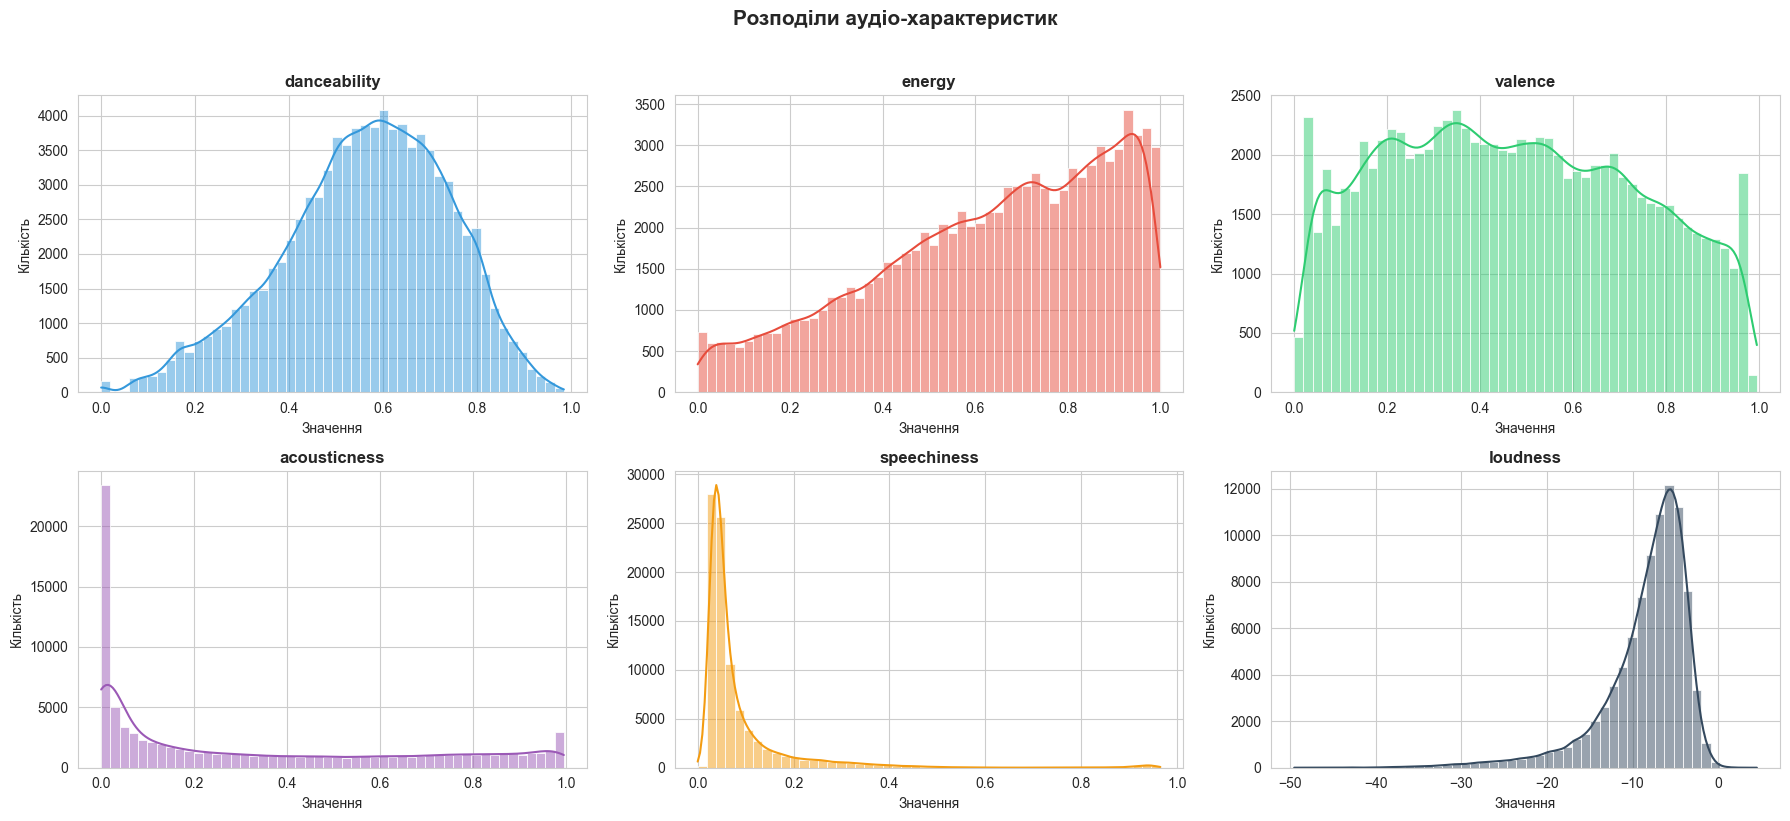

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6',
          '#f39c12', '#34495e']

for i, feat in enumerate(AUDIO_FEATURES):
    row, col = i // 3, i % 3
    sns.histplot(df[feat], bins=50, ax=axes[row, col], color=colors[i], kde=True)
    axes[row, col].set_title(feat, fontsize=12, fontweight='bold')
    axes[row, col].set_xlabel('Значення')
    axes[row, col].set_ylabel('Кількість')

plt.suptitle('Розподіли аудіо-характеристик', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 1.4 Розподіл жанрів

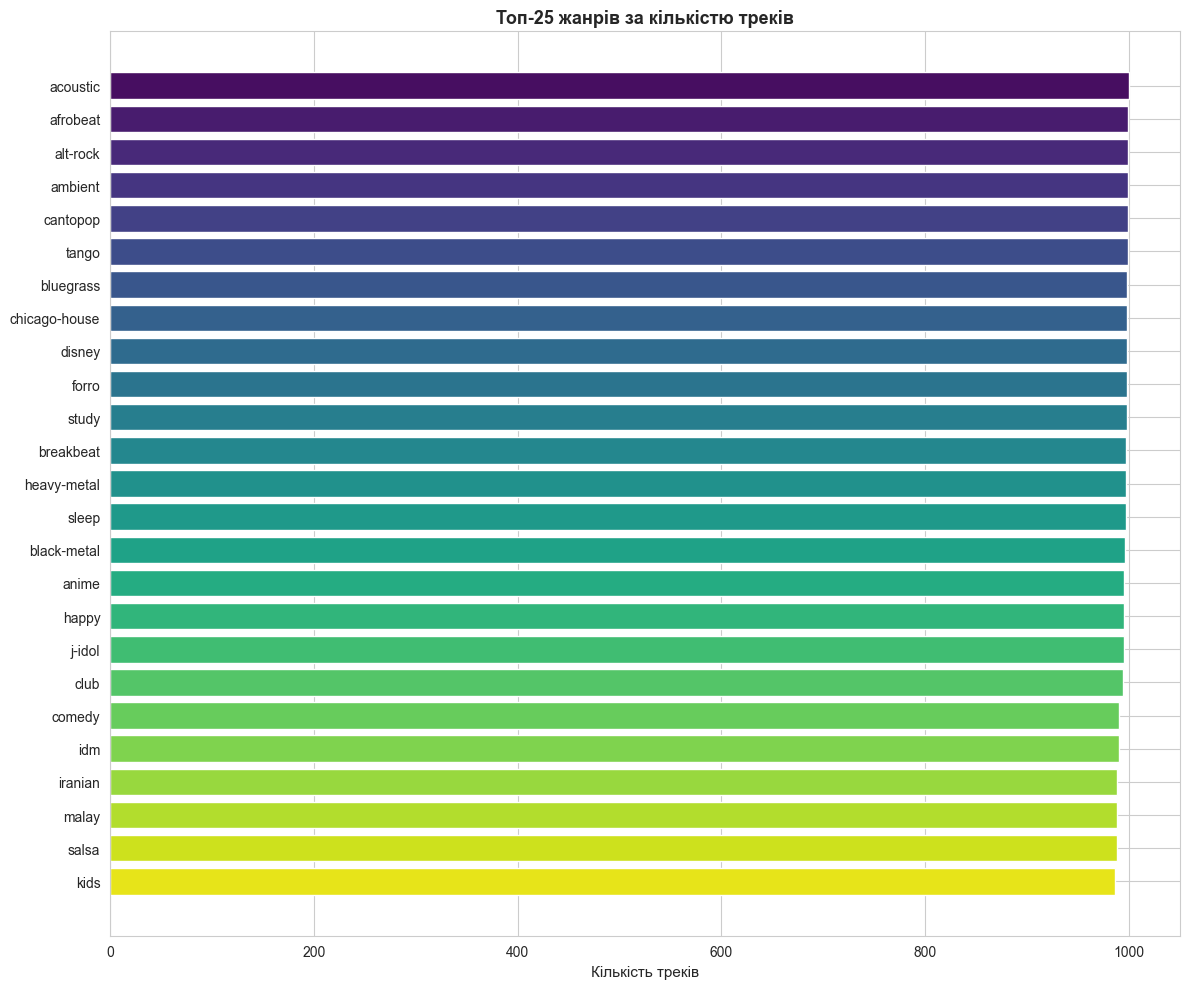

In [7]:
genre_counts = df[GENRE_COL].value_counts()

fig, ax = plt.subplots(figsize=(12, 10))
plot_genre_distribution(genre_counts, 'Топ-25 жанрів за кількістю треків', ax=ax, top_n=25)
plt.tight_layout()
plt.show()

In [8]:
top_genres = get_top_genres(df, TOP_N_GENRES)
top_mask = df[GENRE_COL].isin(top_genres)
coverage = top_mask.sum() / len(df) * 100

print(f"Топ-{TOP_N_GENRES} жанрів: {top_genres}")
print(f"Покриття: {top_mask.sum()} з {len(df)} треків ({coverage:.1f}%)")

Топ-15 жанрів: ['acoustic', 'afrobeat', 'alt-rock', 'ambient', 'cantopop', 'tango', 'bluegrass', 'chicago-house', 'disney', 'forro', 'study', 'breakbeat', 'heavy-metal', 'sleep', 'black-metal']
Покриття: 14972 з 89741 треків (16.7%)


## 1.5 Кореляційний аналіз

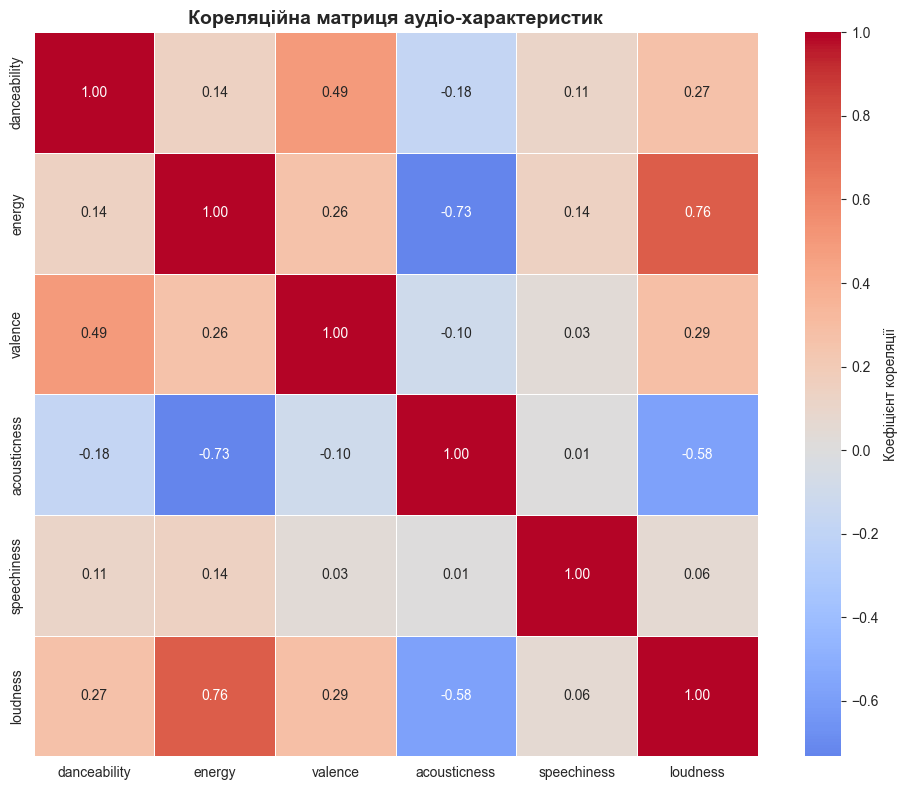

In [9]:
corr_matrix = df[AUDIO_FEATURES].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'label': 'Коефіцієнт кореляції'})
plt.title('Кореляційна матриця аудіо-характеристик', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Інтерпретація кореляцій:**
- **energy ~ loudness** — сильна позитивна кореляція: гучніші треки зазвичай більш енергійні
- **energy ~ acousticness** — сильна негативна кореляція: акустичні треки, як правило, менш енергійні
- Більшість інших пар слабко корелюють, що означає що кожна характеристика несе унікальну інформацію

## 1.6 Boxplot аналіз викидів

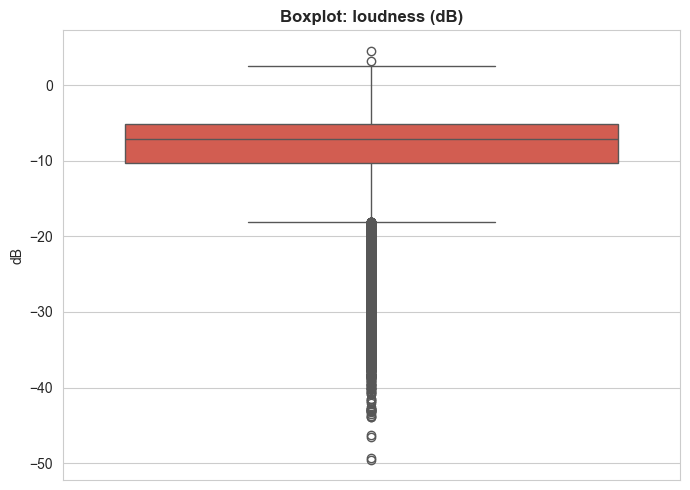

loudness: 5026 викидів (5.6%) — діапазон [-49.5, 4.5]

Викиди відповідають реальним значенням і не видаляються.


In [10]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(y=df['loudness'], ax=ax, color='#e74c3c')
ax.set_title('Boxplot: loudness (dB)', fontsize=12, fontweight='bold')
ax.set_ylabel('dB')

plt.tight_layout()
plt.show()

col = 'loudness'
Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
IQR = Q3 - Q1
outliers = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
print(f"{col}: {outliers} викидів ({outliers / len(df) * 100:.1f}%) — "
      f"діапазон [{df[col].min():.1f}, {df[col].max():.1f}]")

print("\nВикиди відповідають реальним значенням і не видаляються.")

Значення loudness мають статистичні викиди за IQR-критерієм, але вони відповідають реальним музичним характеристикам (тихі інструментальні треки), тому видалення не потрібне.

## 1.7 Збереження підготовлених даних

In [11]:
from src.config import PROCESSED_PATH, SCALED_PATH, BINNED_PATH

df.to_csv(PROCESSED_PATH, index=False)
print(f"data_processed.csv: {df.shape[0]} рядків, {df.shape[1]} стовпців")
print(f"  Стовпці: {list(df.columns)}")

top_genres = get_top_genres(df, TOP_N_GENRES)
df_binned = create_binned(df, top_genres)
df_binned.to_csv(BINNED_PATH, index=False)
print(f"\ndata_binned.csv: {df_binned.shape[0]} рядків, {df_binned.shape[1]} стовпців")
print(f"  Стовпці: {list(df_binned.columns)}")
print(f"  Приклад:")
for col in df_binned.columns:
    print(f"    {col}: {sorted(df_binned[col].unique())}")

df_scaled, scaler = create_scaled(df)
df_scaled.to_csv(SCALED_PATH, index=False)
print(f"\ndata_scaled.csv: {df_scaled.shape[0]} рядків, {df_scaled.shape[1]} стовпців")

print("\nУсі файли збережено до data/")

data_processed.csv: 89741 рядків, 10 стовпців
  Стовпці: ['track_id', 'track_name', 'artists', 'track_genre', 'danceability', 'energy', 'valence', 'acousticness', 'speechiness', 'loudness']

data_binned.csv: 89741 рядків, 7 стовпців
  Стовпці: ['danceability', 'energy', 'valence', 'acousticness', 'speechiness', 'loudness', 'track_genre']
  Приклад:
    danceability: ['High', 'Low', 'Medium']
    energy: ['High', 'Low', 'Medium']
    valence: ['High', 'Low', 'Medium']
    acousticness: ['High', 'Low', 'Medium']
    speechiness: ['High', 'Low', 'Medium']
    loudness: ['Loud', 'Medium', 'Quiet']
    track_genre: ['Other', 'acoustic', 'afrobeat', 'alt-rock', 'ambient', 'black-metal', 'bluegrass', 'breakbeat', 'cantopop', 'chicago-house', 'disney', 'forro', 'heavy-metal', 'sleep', 'study', 'tango']



data_scaled.csv: 89741 рядків, 6 стовпців

Усі файли збережено до data/
